In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



raw_crawled_data = pd.read_csv('cars_packed.csv')
raw_crawled_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24720 entries, 0 to 24719
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Hãng xe    24720 non-null  object
 1   Dòng xe    24720 non-null  object
 2   Giá thành  24720 non-null  int64 
 3   Thông số   24720 non-null  object
dtypes: int64(1), object(3)
memory usage: 772.6+ KB


In [2]:
df = pd.read_csv("cars_packed.csv")
def unpack_specs(spec_str):
    items = [item.strip() for item in spec_str.split(",")]
    data = {}
    for item in items:
        if ":" in item:
            key, value = item.split(":", 1)
            data[key.strip()] = value.strip()
    return pd.Series(data)

specs_df = df["Thông số"].apply(unpack_specs)
df_final = pd.concat([df.drop(columns=["Thông số"]), specs_df], axis=1)


In [3]:
print("=== MẪU DỮ LIỆU ===")
for col in ["Giá thành","Năm sản xuất","Số Km đã đi","Xuất xứ","Kiểu dáng","Hộp số","Tuổi thọ","Loại động cơ", "Dung tích động cơ"]:
    print(f"\n{col}:")
    print(df_final[col].value_counts())

=== MẪU DỮ LIỆU ===

Giá thành:
Giá thành
450000000     184
465000000     167
425000000     154
455000000     154
435000000     153
             ... 
523000000       1
727000000       1
711000000       1
314000000       1
1256000000      1
Name: count, Length: 1864, dtype: int64

Năm sản xuất:
Năm sản xuất
2022    3616
2021    2527
2019    2433
2023    2125
2020    1890
2018    1718
2016    1562
2024    1546
2017    1275
2015    1232
2014     869
2009     546
2025     532
2010     496
2011     468
2013     434
2008     324
2012     316
2007     277
2004     127
2005     104
2006      87
2003      85
2002      37
1989      18
2001      16
2000      12
1997      10
1995       7
1996       6
1999       6
1992       5
1993       5
1998       4
1994       2
1990       2
1991       1
Name: count, dtype: int64

Số Km đã đi:
Số Km đã đi
0          2773
80000       798
50000       747
60000       722
40000       718
           ... 
1170000       1
109200        1
225600        1
21393         1

In [4]:
import re

def convert_price_to_number(price_str):
    if(type(price_str) == int or type(price_str) == float):
        return price_str
    if pd.isna(price_str):
        return np.nan
    
    price_str = str(price_str).lower()
    
    if 'tỷ' in price_str:
        parts = re.findall(r'\d+', price_str)
        if len(parts) >= 2:
            return int(parts[0]) * 1000 + int(parts[1])
        return int(parts[0]) * 1000 
    elif 'triệu' in price_str:
        parts = re.findall(r'\d+', price_str)
        return int(parts[0])
    
    return np.nan

def convert_km_to_number(km_str):
    if pd.isna(km_str):
        return np.nan
    
    km_str = str(km_str).replace(',', '').replace('Km', '').replace('km', '').strip()
    try:
        return int(km_str)
    except:
        return np.nan
    
def extract_engine_capacity(engine_str):
    if pd.isna(engine_str):
        return np.nan
    
    match = re.search(r'(\d+\.?\d*)\s*L', str(engine_str))
    if match:
        return float(match.group(1))
    return np.nan
    
def extract_engine_type(engine_str):
    if pd.isna(engine_str):
        return np.nan
    
    engine_str = str(engine_str).lower()
    engine_type = engine_str.split()[0]		
    if engine_type in ['xăng', 'dầu', 'điện', 'hybrid']:
        return engine_type
    return np.nan

data_clean = pd.DataFrame()
data_clean['Hãng xe'] = df_final['Hãng xe'].apply(lambda x: str(x).lower())
data_clean['Dòng xe'] = df_final['Dòng xe'].apply(lambda x: str(x).lower())
data_clean['Giá thành'] = df_final['Giá thành'].apply(convert_price_to_number)
data_clean['Năm sản xuất'] = pd.to_numeric(df_final['Năm sản xuất'], errors='coerce')
data_clean['Số Km đã đi'] = df_final['Số Km đã đi'].apply(convert_km_to_number)
data_clean['Dung tích động cơ'] = df_final['Dung tích động cơ'].apply(lambda x: str(x).lower())
data_clean['Loại động cơ'] = df_final['Loại động cơ'].apply(lambda x: str(x).lower())
data_clean['Hộp số'] = df_final['Hộp số'].apply(lambda x: str(x).lower())
data_clean['Xuất xứ'] = df_final['Xuất xứ'].apply(lambda x: str(x).lower())
data_clean['Kiểu dáng'] = df_final['Kiểu dáng'].apply(lambda x: str(x).lower())
df = pd.read_csv("crawl_results.csv")
data_clean["Tuổi thọ"] = (pd.Timestamp.now() - pd.to_datetime(df["posted_date"], format="%d/%m/%Y", errors="coerce")).dt.days


In [5]:
# xử lý giá trị thiếu và giá trị ngoại lai
# Kiểm tra thông tin dữ liệu
data_clean.info()
print(data_clean['Loại động cơ'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24720 entries, 0 to 24719
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Hãng xe            24720 non-null  object
 1   Dòng xe            24720 non-null  object
 2   Giá thành          24720 non-null  int64 
 3   Năm sản xuất       24720 non-null  int64 
 4   Số Km đã đi        24720 non-null  int64 
 5   Dung tích động cơ  24720 non-null  object
 6   Loại động cơ       24720 non-null  object
 7   Hộp số             24720 non-null  object
 8   Xuất xứ            24720 non-null  object
 9   Kiểu dáng          24720 non-null  object
 10  Tuổi thọ           24720 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 2.1+ MB
Loại động cơ
xăng      20115
dầu        3747
điện        543
hybrid      315
Name: count, dtype: int64


In [6]:
# Kiểm tra các giá trị duy nhất trước fill
print(data_clean['Loại động cơ'].value_counts())

# Kiểm tra kiểu dữ liệu
print(data_clean['Loại động cơ'].dtype)

# Xem xem giá trị "điện" có bị lỗi khoảng trắng/format không
print(data_clean[data_clean['Loại động cơ'].str.contains("điện", na=False)])


Loại động cơ
xăng      20115
dầu        3747
điện        543
hybrid      315
Name: count, dtype: int64
object
             Hãng xe                         Dòng xe   Giá thành  \
10     mercedes benz                    eqb 250 2024  2239000000   
153          vinfast                   vf3 plus 2024   229000000   
163    mercedes benz             eqs 500 4matic 2024  4379000000   
231          vinfast                   vf3 plus 2024   239000000   
232          vinfast                   vf3 plus 2024   239000000   
...              ...                             ...         ...   
24394        vinfast                   vf9 plus 2023   999000000   
24413        vinfast                   vf6 plus 2024   680000000   
24433         wuling  hongguang miniev nang cao 2023   175000000   
24510        vinfast                   vf3 plus 2024   227000000   
24702        vinfast                    vf8 eco 2023   769000000   

       Năm sản xuất  Số Km đã đi Dung tích động cơ Loại động cơ      Hộp 

In [7]:
from sklearn.impute import SimpleImputer
categorical_cols = ["Hãng xe", "Dòng xe", "Xuất xứ", "Kiểu dáng", "Hộp số", "Loại động cơ"]
numeric_cols = ["Năm sản xuất", "Số Km đã đi", "Tuổi thọ", "Dung tích động cơ"]
data_clean['Số Km đã đi'] = data_clean['Số Km đã đi'].replace(0, np.nan)

# Fill NaN
print("NaN trước khi fill:\n", data_clean.isna().sum()[data_clean.isna().sum() > 0])
data_clean[categorical_cols] = data_clean[categorical_cols].fillna("unknown")
imputer = SimpleImputer(strategy="mean")
data_clean[numeric_cols] = imputer.fit_transform(data_clean[numeric_cols])
print("\nNaN sau khi fill:\n", data_clean.isna().sum()[data_clean.isna().sum() > 0])
print(data_clean['Loại động cơ'].value_counts())

NaN trước khi fill:
 Số Km đã đi    2773
dtype: int64

NaN sau khi fill:
 Series([], dtype: int64)
Loại động cơ
xăng      20115
dầu        3747
điện        543
hybrid      315
Name: count, dtype: int64


In [8]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
print(data_clean['Loại động cơ'].value_counts())
data_clean.to_csv("before_iqr.csv")
data_clean = remove_outliers_iqr(data_clean, 'Giá thành')
data_clean = remove_outliers_iqr(data_clean, 'Số Km đã đi')
data_clean = remove_outliers_iqr(data_clean, 'Tuổi thọ')
data_clean = remove_outliers_iqr(data_clean, "Năm sản xuất")

data_clean.info()
print(data_clean['Loại động cơ'].value_counts())
data_clean.to_csv("after_iqr.csv")

Loại động cơ
xăng      20115
dầu        3747
điện        543
hybrid      315
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 18662 entries, 0 to 21914
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Hãng xe            18662 non-null  object 
 1   Dòng xe            18662 non-null  object 
 2   Giá thành          18662 non-null  int64  
 3   Năm sản xuất       18662 non-null  float64
 4   Số Km đã đi        18662 non-null  float64
 5   Dung tích động cơ  18662 non-null  float64
 6   Loại động cơ       18662 non-null  object 
 7   Hộp số             18662 non-null  object 
 8   Xuất xứ            18662 non-null  object 
 9   Kiểu dáng          18662 non-null  object 
 10  Tuổi thọ           18662 non-null  float64
dtypes: float64(4), int64(1), object(6)
memory usage: 1.7+ MB
Loại động cơ
xăng      14832
dầu        3215
điện        464
hybrid      151
Name: count, dtype: int64


In [9]:
import numpy as np

print("Trước khi log-transform:")
print(data_clean[["Số Km đã đi", "Giá thành"]].describe())

# Log-transform để giảm lệch phân phối
data_clean["Số Km đã đi"] = np.log1p(data_clean["Số Km đã đi"])
data_clean["Giá thành"] = np.log1p(data_clean["Giá thành"])

print("\nSau khi log-transform:")
print(data_clean[["Số Km đã đi", "Giá thành"]].describe())
print(len(data_clean[data_clean['Số Km đã đi'] == 0]))
print(len(data_clean))

Trước khi log-transform:
         Số Km đã đi     Giá thành
count   18662.000000  1.866200e+04
mean    76472.281714  7.126261e+08
std     53339.582195  4.549502e+08
min         1.000000  4.500000e+07
25%     37000.000000  3.950000e+08
50%     67000.000000  5.750000e+08
75%    100000.000000  8.900000e+08
max    218000.000000  2.239000e+09

Sau khi log-transform:
        Số Km đã đi     Giá thành
count  18662.000000  18662.000000
mean      10.832652     20.192543
std        1.289865      0.631672
min        0.693147     17.622173
25%       10.518700     19.794396
50%       11.112463     20.169881
75%       11.512935     20.606732
max       12.292255     21.529295
0
18662


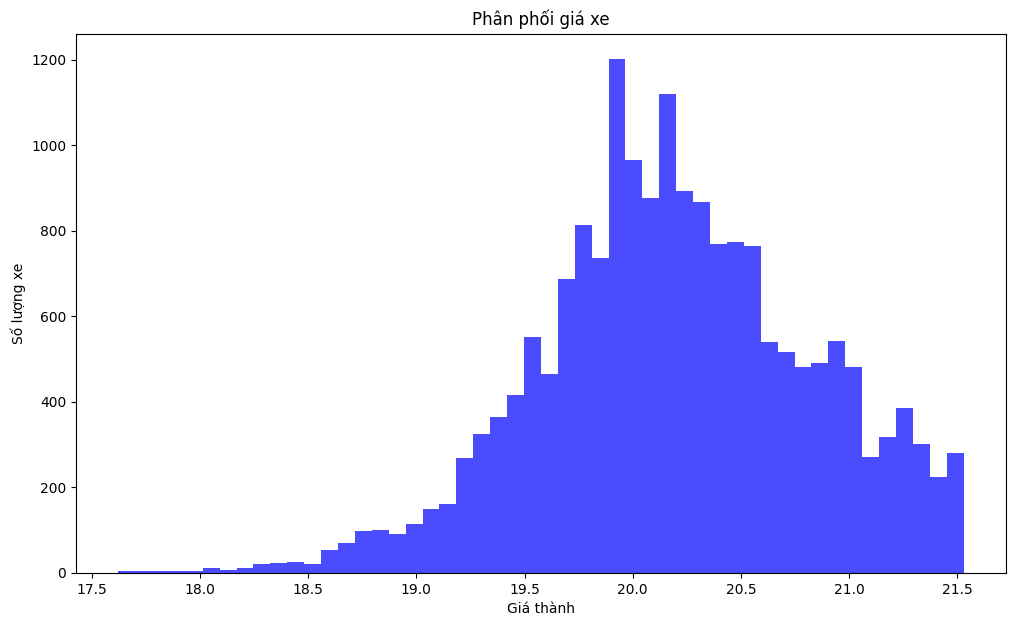

In [10]:
# vẽ biểu đồ phân phối giá
plt.figure(figsize=(12, 7))
plt.hist(data_clean['Giá thành'], bins=50, color='blue', alpha=0.7)
plt.title('Phân phối giá xe')
plt.xlabel('Giá thành')
plt.ylabel('Số lượng xe')
plt.show()

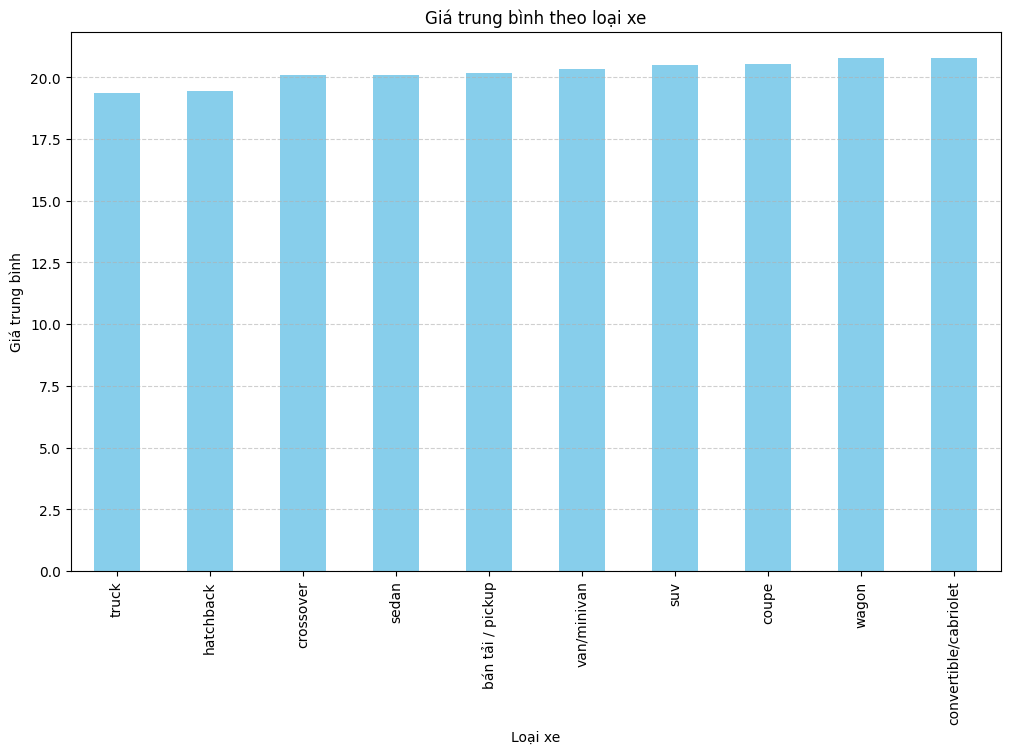

In [11]:
# Biểu đồ giá xe theo loại xe
plt.figure(figsize=(12, 7))
data_clean.groupby('Kiểu dáng')['Giá thành'].mean().sort_values().plot(kind='bar', color='skyblue')
plt.title('Giá trung bình theo loại xe')
plt.xlabel('Loại xe')
plt.ylabel('Giá trung bình')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

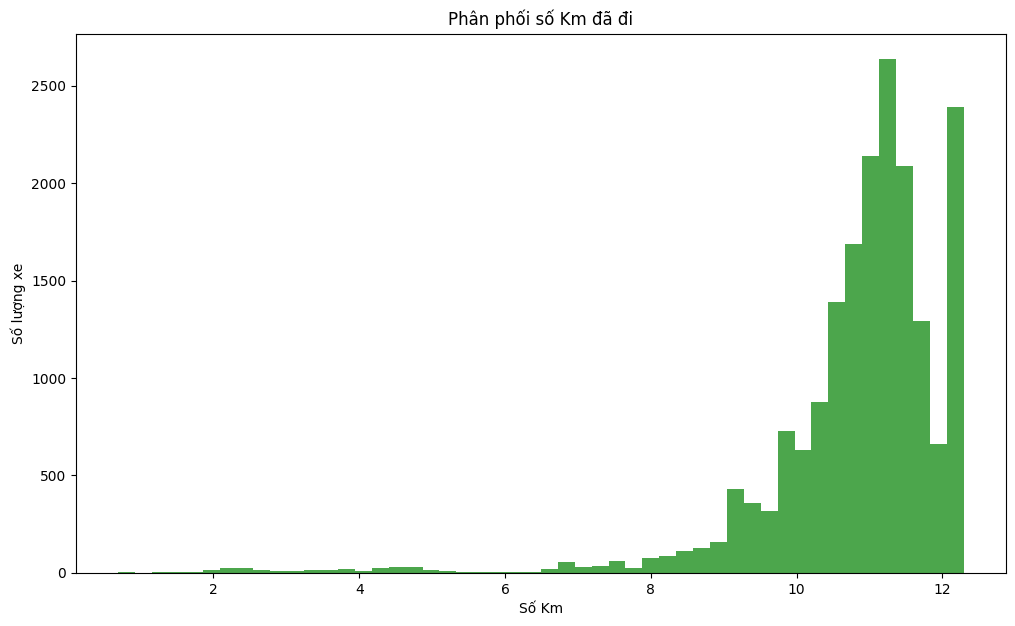

In [12]:
# biểu đồ phân phối số km đã đi
plt.figure(figsize=(12, 7))
plt.hist(data_clean['Số Km đã đi'], bins=50, color='green', alpha=0.7)
plt.title('Phân phối số Km đã đi')
plt.xlabel('Số Km')
plt.ylabel('Số lượng xe')
plt.show()

In [13]:
print(data_clean['Loại động cơ'].value_counts())
data_clean.to_csv("data_cleaned")

Loại động cơ
xăng      14832
dầu        3215
điện        464
hybrid      151
Name: count, dtype: int64


Loại động cơ
xăng      14832
dầu        3215
điện        464
hybrid      151
Name: count, dtype: int64


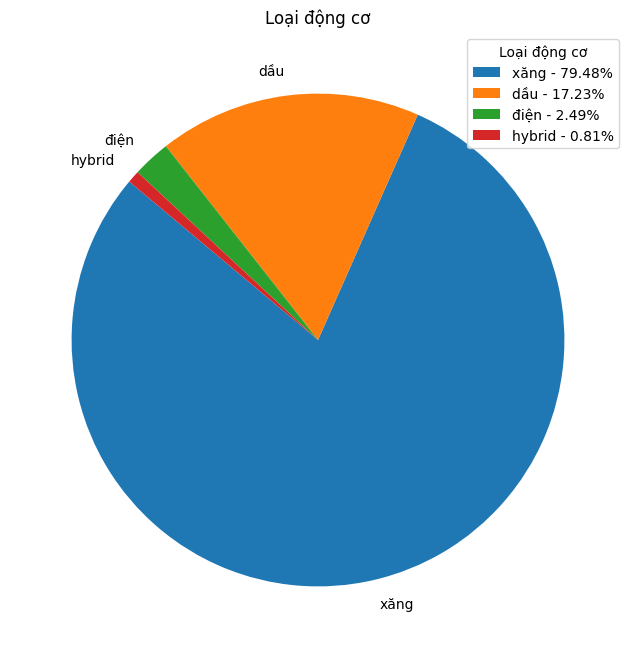

In [14]:
# biểu đồ tròn phân bố loại động cơ, không hiển thị phần trăm trên biểu đồ, hiện trên chú giải cả số %
engine_type_counts = data_clean['Loại động cơ'].value_counts()
print(engine_type_counts)
plt.figure(figsize=(10, 8))
plt.pie(engine_type_counts, labels=engine_type_counts.index, startangle=140)
plt.title('Loại động cơ')
plt.legend(title='Loại động cơ', loc='upper right', labels=[f"{i} - {j/engine_type_counts.sum()*100:.2f}%" for i, j in zip(engine_type_counts.index, engine_type_counts)])
plt.show()

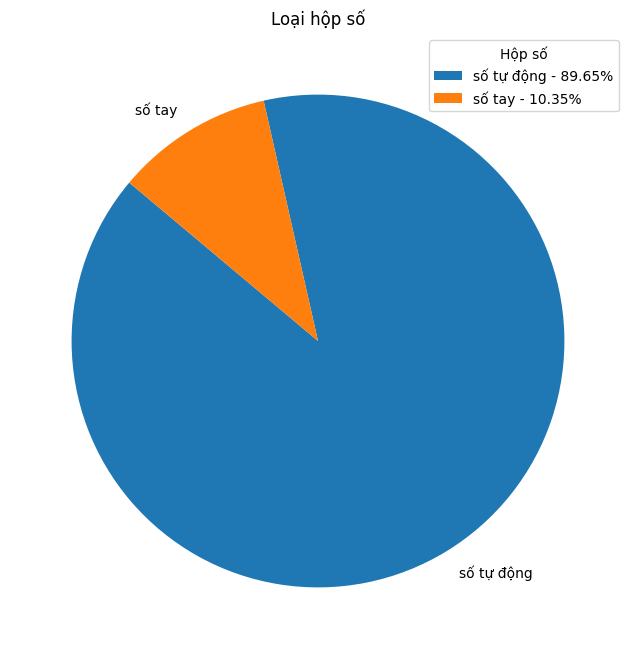

In [15]:
# biểu đồ tròn phân bố hộp số
transmission_type_counts = data_clean['Hộp số'].value_counts()
plt.figure(figsize=(10, 8))
plt.pie(transmission_type_counts, labels=transmission_type_counts.index, startangle=140)
plt.title('Loại hộp số')
plt.legend(title='Hộp số', loc='upper right', labels=[f"{i} - {j/transmission_type_counts.sum()*100:.2f}%" for i, j in zip(transmission_type_counts.index, transmission_type_counts)])
plt.show()

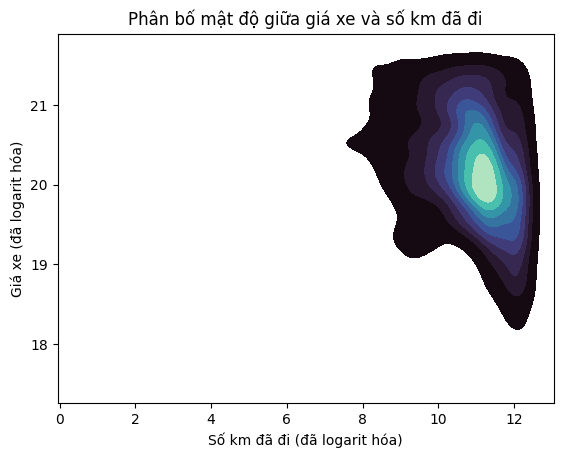

In [16]:
import seaborn as sns
sns.kdeplot(
    x='Số Km đã đi',
    y='Giá thành',
    data=data_clean,
    fill=True,
    cmap='mako',
    thresh=0.05
)
plt.title('Phân bố mật độ giữa giá xe và số km đã đi')
plt.xlabel('Số km đã đi (đã logarit hóa)')
plt.ylabel('Giá xe (đã logarit hóa)')
plt.show()